## 붓꽃 데이터 분석
## 라이브러리 불러오기

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns #시본

## 붓꽃(아이리스) 데이터 불러오기

In [3]:
iris = sns.load_dataset('iris')

In [4]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [7]:
# 기초 통계량
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
#품종
iris['species']

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: str

In [10]:
# 품목별 데이터 개수
iris['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [11]:
# count 이름의 데이터 프레임
count = pd.DataFrame(iris['species'].value_counts())

In [12]:
count

,count
species,
setosa,50
versicolor,50
virginica,50


### 결측치 확인

In [14]:
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

### 중복 데이터 확인

In [17]:
iris.duplicated().sum()

np.int64(1)

In [19]:
index = iris.duplicated()
index.head()

0    False
1    False
2    False
3    False
4    False
dtype: bool

In [20]:
# loc[행, 열]
iris.loc[index,:]

,sepal_length,sepal_width,petal_length,petal_width,species
142,5.8,2.7,5.1,1.9,virginica


In [22]:
result = (iris['sepal_length']==5.8) & (iris['petal_width']==1.9)
iris.loc[result,:]

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


### 중복데이터 삭제 --> drop_duplicates()

In [24]:
iris = iris.drop_duplicates()

In [25]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [26]:
iris.loc[result,:]

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica


## 데이터 그룹핑

In [27]:
iris.groupby('species').sum()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,250.3,171.4,73.1,12.3
versicolor,296.8,138.5,213.0,66.3
virginica,323.6,146.0,272.5,99.4


In [28]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006000,3.428000,1.462000,0.246000
versicolor,5.936000,2.770000,4.260000,1.326000
virginica,6.604082,2.979592,5.561224,2.028571


# 데이터 시각화

In [29]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


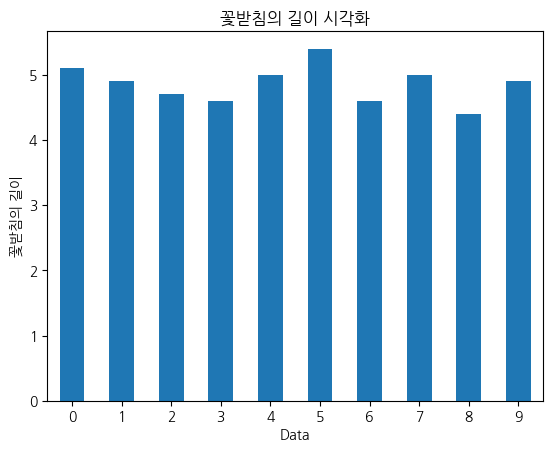

In [31]:
## 꽃받침의 길이 시각화 - 막대그래프
iris.sepal_length[:10].plot(kind='bar', rot=0)
plt.title('꽃받침의 길이 시각화')
plt.xlabel('Data')
plt.ylabel('꽃받침의 길이')
plt.show()

In [33]:
# 붓꽃의 품종별 그룹화 - 평균 - 새로운 데이터프레임으로 저장 - 시각화

df2 = iris.groupby(iris['species']).mean()
df2

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006000,3.428000,1.462000,0.246000
versicolor,5.936000,2.770000,4.260000,1.326000
virginica,6.604082,2.979592,5.561224,2.028571


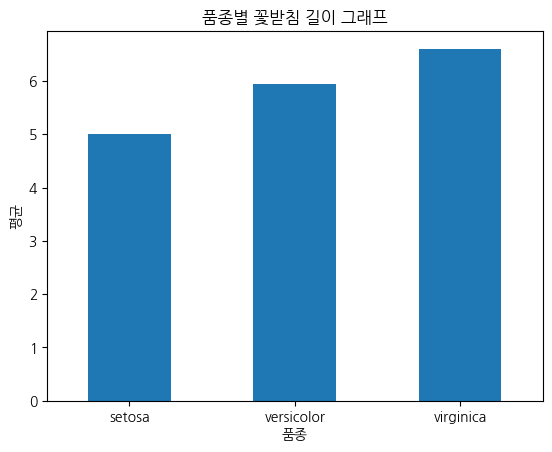

In [37]:
# 품종별 꽃받침 길이 그래프
df2.sepal_length[:].plot(kind='bar', rot=0)
plt.title('품종별 꽃받침 길이 그래프')
plt.xlabel('품종')
plt.ylabel('평균')
plt.show()

## 히스토그램

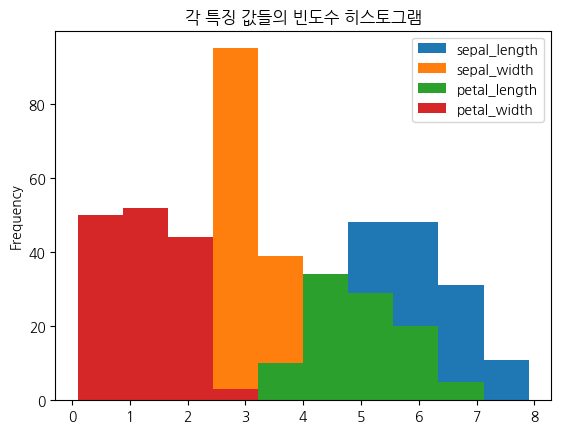

In [40]:
iris.plot(kind='hist')
plt.title('각 특징 값들의 빈도수 히스토그램')
plt.show()

## 상자 그래프 --> 이상치 발견

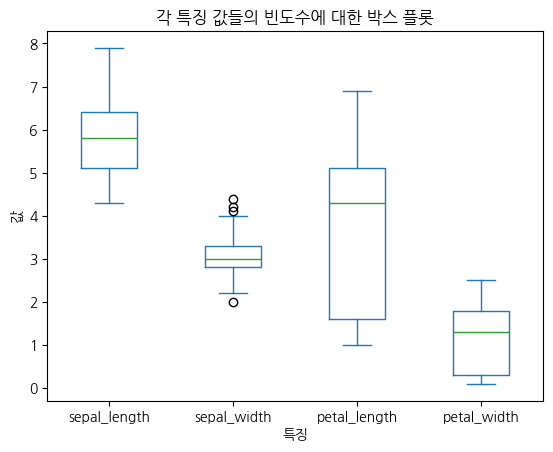

In [41]:
iris.plot(kind='box')
plt.title('각 특징 값들의 빈도수에 대한 박스 플롯')
plt.xlabel('특징')
plt.ylabel('값')
plt.show()

## 산점도 그래프 (산포그래프)

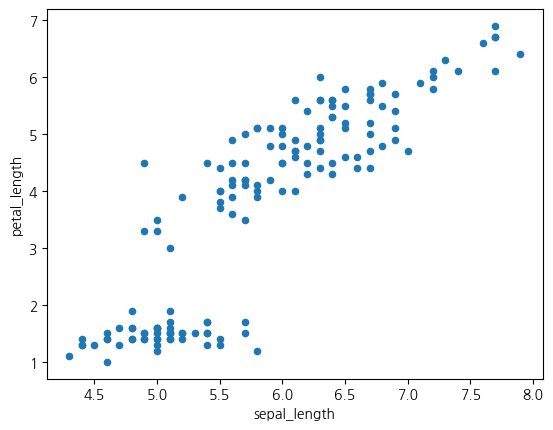

In [42]:
iris.plot(x='sepal_length', y = 'petal_length', kind='scatter')
plt.show()

In [43]:
# 1
iris.groupby(iris['species']).max()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.8,4.4,1.9,0.6
versicolor,7.0,3.4,5.1,1.8
virginica,7.9,3.8,6.9,2.5


In [44]:
iris.groupby(iris['species']).min()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,4.3,2.3,1.0,0.1
versicolor,4.9,2.0,3.0,1.0
virginica,4.9,2.2,4.5,1.4


In [46]:
iris = iris.rename(columns={'sepal_length':'SL',	'sepal_width':'SW',	'petal_length':'PL',	'petal_width':'PW'})
iris.head()

,SL,SW,PL,PW,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [59]:
#2
import seaborn as sns
tips = sns.load_dataset('tips')
tips.head()

n_iris = iris.copy()

In [61]:
# 컬럼 바꾸는 또다른 방법
# n_iris.columns = ['SL', 'SW', 'PL', 'PW', 'species']

In [49]:
tips1 = tips.sort_values(by=['total_bill','tip'])
tips1[:10]

,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
92,5.75,1.00,Female,Yes,Fri,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
172,7.25,5.15,Male,Yes,Sun,Dinner,2
149,7.51,2.00,Male,No,Thur,Lunch,2
195,7.56,1.44,Male,No,Thur,Lunch,2
218,7.74,1.44,Male,Yes,Sat,Dinner,2
145,8.35,1.50,Female,No,Thur,Lunch,2
135,8.51,1.25,Female,No,Thur,Lunch,2
126,8.52,1.48,Male,No,Thur,Lunch,2


In [50]:
tips2 = tips.sort_values(by=['size','tip'],ascending=[False,True])
tips2[:10]

,total_bill,tip,sex,smoker,day,time,size
125,29.80,4.20,Female,No,Thur,Lunch,6
143,27.05,5.00,Female,No,Thur,Lunch,6
156,48.17,5.00,Male,No,Sun,Dinner,6
141,34.30,6.70,Male,No,Thur,Lunch,6
187,30.46,2.00,Male,Yes,Sun,Dinner,5
216,28.15,3.00,Male,Yes,Sat,Dinner,5
142,41.19,5.00,Male,No,Thur,Lunch,5
185,20.69,5.00,Male,No,Sun,Dinner,5
155,29.85,5.14,Female,No,Sun,Dinner,5
153,24.55,2.00,Male,No,Sun,Dinner,4


In [65]:
# 3
iris = sns.load_dataset('iris')
iris.columns = ['SL', 'SW', 'PL', 'PW', 'species']
iris.sort_values(by='SW',ascending=False)

,SL,SW,PL,PW,species
15,5.7,4.4,1.5,0.4,setosa
33,5.5,4.2,1.4,0.2,setosa
32,5.2,4.1,1.5,0.1,setosa
14,5.8,4.0,1.2,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
...,...,...,...,...,...
53,5.5,2.3,4.0,1.3,versicolor
62,6.0,2.2,4.0,1.0,versicolor
68,6.2,2.2,4.5,1.5,versicolor
119,6.0,2.2,5.0,1.5,virginica


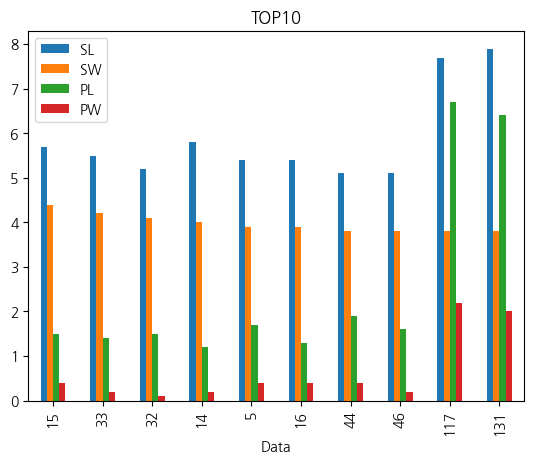

In [66]:
iris1 = iris.sort_values(by='SW',ascending=False)
iris1[:10].plot(kind='bar')
plt.title('TOP10')
plt.xlabel('Data')
plt.show()


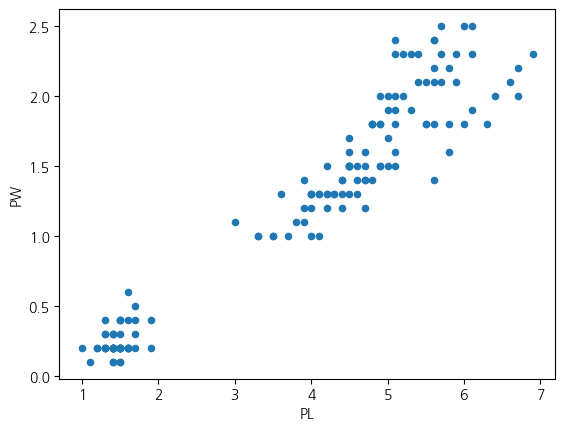

In [58]:
iris.plot(x='PL', y = 'PW', kind='scatter')
plt.show()

In [67]:
#4
titanic = pd.read_csv('train.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [72]:
titanic2 = titanic[['Sex','Survived']]
titanic2.groupby(by=titanic2['Sex']).mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [73]:
titanic2 = titanic[['Parch','Survived']]
titanic2.groupby(by=titanic2['Parch']).mean()

,Survived
Parch,
0,0.343658
1,0.550847
2,0.500000
3,0.600000
4,0.000000
5,0.200000
6,0.000000


In [79]:
titanic2.groupby('Parch',as_index=False).mean().sort_values('Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [75]:
titanic3 = titanic[['Pclass','Sex','Survived','Age']]
titanic3.groupby(by=['Pclass','Sex']).mean()

Survived        Age
Pclass Sex                        
1      female  0.968085  34.611765
       male    0.368852  41.281386
2      female  0.921053  28.722973
       male    0.157407  30.740707
3      female  0.500000  21.750000
       male    0.135447  26.507589

#### 데이터프레임명.groupby(['컬럼1','컬럼2'])[내가 계산하고 싶은 컬럼들].원하는 계산함수()

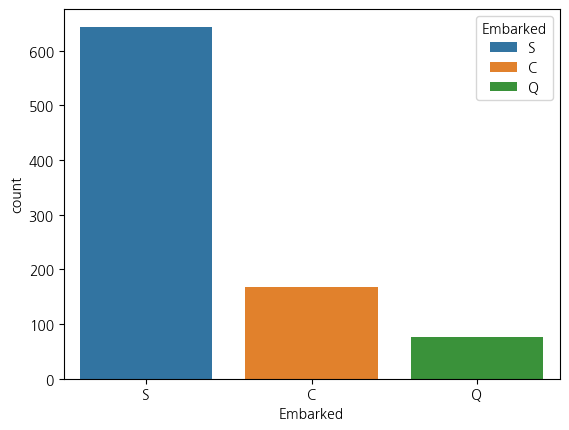

In [ ]:
titanic5 = titanic[['Survived','Embarked']]
# titanic5.groupby(by='Embarked')

# titanic5.plot(kind='bar')
# plt.show()

sns.countplot(titanic5, x='Embarked', hue='Embarked') #hue 색상 변경
plt.show()

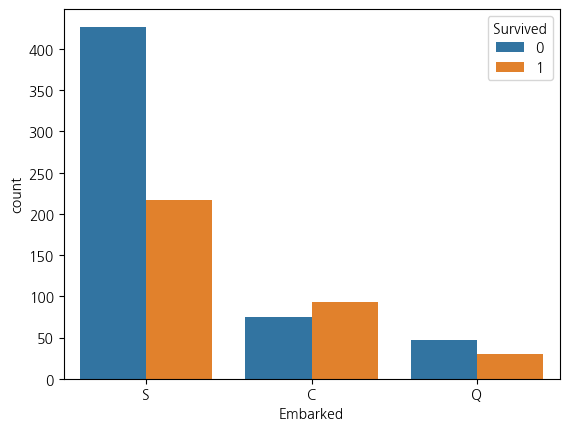

In [ ]:
sns.countplot(titanic5, x='Embarked', hue='Survived') #hue 색상 변경
plt.show() 